<a href="https://colab.research.google.com/github/8009678200/ML.github.io/blob/main/Copy_of_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Web Scraping Project

To get started with web scraping, we'll need two main libraries: `requests` to fetch web page content and `BeautifulSoup` (`bs4`) to parse the HTML and extract data.

In [ ]:
# Install the 'requests' library to make HTTP requests
!pip install requests

In [ ]:
# Install 'BeautifulSoup' for parsing HTML content
!pip install beautifulsoup4

Now that the libraries are installed, let's write a basic script to fetch the content of a website and parse it. We'll use a simple example website for this demonstration.

In [ ]:
import requests
from bs4 import BeautifulSoup

# Define the URL of the website to scrape
url = 'http://quotes.toscrape.com/' # A website specifically designed for scraping demonstrations

# Send an HTTP GET request to the URL
response = requests.get(url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    print(f"Successfully fetched {url}")
    # Parse the HTML content of the page
    soup = BeautifulSoup(response.text, 'html.parser')
    print("HTML content parsed successfully. Displaying the title:")
    print(soup.title.text)
else:
    print(f"Failed to fetch {url}. Status code: {response.status_code}")


Successfully fetched http://quotes.toscrape.com/
HTML content parsed successfully. Displaying the title:
Quotes to Scrape


The above code fetches the homepage of `quotes.toscrape.com` and prints its title. Now, let's display the first few paragraphs of the page to see some of the content.

In [ ]:
from bs4 import BeautifulSoup

# Assuming 'response' and 'soup' objects are available from the previous cell's execution
# If you run this cell independently, you'll need to re-run the previous cell first or redefine 'soup'

# Find all paragraph tags and print their text
paragraphs = soup.find_all('p')

print("\nFirst 3 paragraphs on the page:")
for i, p in enumerate(paragraphs[:3]):
    print(f"Paragraph {i+1}: {p.text.strip()}")



First 3 paragraphs on the page:
Paragraph 1: Login
Paragraph 2: Quotes by: GoodReads.com
Paragraph 3: Made with ❤ by Zyte


The primary goal of `quotes.toscrape.com` is to provide quotes. Let's extract all the quotes and their authors from the first page. By inspecting the page's HTML (e.g., using your browser's developer tools), we can identify the relevant HTML tags and classes.

In [ ]:
from bs4 import BeautifulSoup

# Assuming 'soup' object is available from the previous cell's execution

# Find all div elements with class 'quote'
quotes = soup.find_all('div', class_='quote')

print("\n--- Extracted Quotes and Authors ---")
for i, quote in enumerate(quotes):
    # Extract the text of the quote
    text = quote.find('span', class_='text').text
    # Extract the author of the quote
    author = quote.find('small', class_='author').text
    print(f"Quote {i+1}:")
    print(f"  Text: {text}")
    print(f"  Author: {author}")
    print("------------------------------------")



--- Extracted Quotes and Authors ---
Quote 1:
  Text: “The truth." Dumbledore sighed. "It is a beautiful and terrible thing, and should therefore be treated with great caution.”
  Author: J.K. Rowling
------------------------------------
Quote 2:
  Text: “I'm the one that's got to die when it's time for me to die, so let me live my life the way I want to.”
  Author: Jimi Hendrix
------------------------------------
Quote 3:
  Text: “To die will be an awfully big adventure.”
  Author: J.M. Barrie
------------------------------------
Quote 4:
  Text: “It takes courage to grow up and become who you really are.”
  Author: E.E. Cummings
------------------------------------
Quote 5:
  Text: “But better to get hurt by the truth than comforted with a lie.”
  Author: Khaled Hosseini
------------------------------------
Quote 6:
  Text: “You never really understand a person until you consider things from his point of view... Until you climb inside of his skin and walk around in it.”
  Author: H

This code extracts each quote and its author. We can also extract the tags associated with each quote.

In [ ]:
from bs4 import BeautifulSoup

# Assuming 'soup' object is available from previous cells

# Find all div elements with class 'quote'
quotes = soup.find_all('div', class_='quote')

print("\n--- Extracted Quotes, Authors, and Tags ---")
for i, quote in enumerate(quotes):
    text = quote.find('span', class_='text').text
    author = quote.find('small', class_='author').text

    # Extract all tags for the current quote
    tags_elements = quote.find('div', class_='tags').find_all('a', class_='tag')
    tags = [tag.text for tag in tags_elements]

    print(f"Quote {i+1}:")
    print(f"  Text: {text}")
    print(f"  Author: {author}")
    print(f"  Tags: {', '.join(tags)}")
    print("------------------------------------")



--- Extracted Quotes, Authors, and Tags ---
Quote 1:
  Text: “The truth." Dumbledore sighed. "It is a beautiful and terrible thing, and should therefore be treated with great caution.”
  Author: J.K. Rowling
  Tags: truth
------------------------------------
Quote 2:
  Text: “I'm the one that's got to die when it's time for me to die, so let me live my life the way I want to.”
  Author: Jimi Hendrix
  Tags: death, life
------------------------------------
Quote 3:
  Text: “To die will be an awfully big adventure.”
  Author: J.M. Barrie
  Tags: adventure, love
------------------------------------
Quote 4:
  Text: “It takes courage to grow up and become who you really are.”
  Author: E.E. Cummings
  Tags: courage
------------------------------------
Quote 5:
  Text: “But better to get hurt by the truth than comforted with a lie.”
  Author: Khaled Hosseini
  Tags: life
------------------------------------
Quote 6:
  Text: “You never really understand a person until you consider things fr

Now, let's tackle pagination. Most websites have multiple pages of content. To scrape all quotes, we need to find the 'Next' button or link and follow it until there are no more pages.

By inspecting `quotes.toscrape.com`, we can see that the 'Next' button is typically within a `li` tag with class `next`.

In [ ]:
import requests
from bs4 import BeautifulSoup

all_quotes_data = [] # To store all extracted quotes
base_url = 'http://quotes.toscrape.com/'
current_url = base_url

while True:
    print(f"\nScraping page: {current_url}")
    response = requests.get(current_url)

    if response.status_code != 200:
        print(f"Failed to retrieve page {current_url}. Status code: {response.status_code}")
        break

    soup = BeautifulSoup(response.text, 'html.parser')
    quotes = soup.find_all('div', class_='quote')

    for quote in quotes:
        text = quote.find('span', class_='text').text.strip()
        author = quote.find('small', class_='author').text.strip()
        tags_elements = quote.find('div', class_='tags').find_all('a', class_='tag')
        tags = [tag.text for tag in tags_elements]

        all_quotes_data.append({
            'text': text,
            'author': author,
            'tags': tags
        })

    # Find the 'Next' button/link
    next_link = soup.find('li', class_='next')
    if next_link and next_link.find('a'):
        next_page_relative_url = next_link.find('a')['href']
        current_url = base_url + next_page_relative_url
    else:
        print("No more pages to scrape.")
        break

print(f"\nTotal quotes scraped: {len(all_quotes_data)}")
print("First 5 scraped quotes:")
for i, quote in enumerate(all_quotes_data[:5]):
    print(f"  {i+1}. Text: {quote['text']}")
    print(f"     Author: {quote['author']}")
    print(f"     Tags: {', '.join(quote['tags'])}")



Scraping page: http://quotes.toscrape.com/

Scraping page: http://quotes.toscrape.com//page/2/

Scraping page: http://quotes.toscrape.com//page/3/

Scraping page: http://quotes.toscrape.com//page/4/

Scraping page: http://quotes.toscrape.com//page/5/

Scraping page: http://quotes.toscrape.com//page/6/

Scraping page: http://quotes.toscrape.com//page/7/

Scraping page: http://quotes.toscrape.com//page/8/

Scraping page: http://quotes.toscrape.com//page/9/

Scraping page: http://quotes.toscrape.com//page/10/
No more pages to scrape.

Total quotes scraped: 100
First 5 scraped quotes:
  1. Text: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
     Author: Albert Einstein
     Tags: change, deep-thoughts, thinking, world
  2. Text: “It is our choices, Harry, that show what we truly are, far more than our abilities.”
     Author: J.K. Rowling
     Tags: abilities, choices
  3. Text: “There are only two ways to live your lif

We've now successfully scraped quotes from all pages! The `all_quotes_data` list contains dictionaries, each representing a quote with its text, author, and associated tags. This structured data is much more useful for analysis or storage.

After successfully scraping all the data, it's best practice to save it. We can save the `all_quotes_data` (which is a list of dictionaries) into a CSV file using the pandas library.

In [ ]:
import pandas as pd

# Convert the list of dictionaries to a pandas DataFrame
df_quotes = pd.DataFrame(all_quotes_data)

# Display the first few rows of the DataFrame
print("\nDataFrame Head:")
display(df_quotes.head())

# Save the DataFrame to a CSV file
csv_filename = 'quotes.csv'
df_quotes.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"\nSuccessfully saved {len(df_quotes)} quotes to '{csv_filename}'")



DataFrame Head:


,text,author,tags
0,“The world as we have created it is a process ...,Albert Einstein,"[change, deep-thoughts, thinking, world]"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"[abilities, choices]"
2,“There are only two ways to live your life. On...,Albert Einstein,"[inspirational, life, live, miracle, miracles]"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"[aliteracy, books, classic, humor]"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"[be-yourself, inspirational]"



Successfully saved 100 quotes to 'quotes.csv'


The quotes are now saved in `quotes.csv`. You can download this file from the Colab environment. If you want to continue analyzing the data, we can start by looking at the most frequent authors or tags.

Let's analyze the `df_quotes` DataFrame to find out the most frequent authors and tags. This will give us an overview of the most prominent themes and contributors in our scraped dataset.

In [ ]:
import pandas as pd

# Assuming df_quotes DataFrame is already loaded from the previous steps
# If running this cell independently, you might need to reload the CSV:
# df_quotes = pd.read_csv('quotes.csv')

print("\n--- Top 10 Most Frequent Authors ---")
# Count the occurrences of each author
author_counts = df_quotes['author'].value_counts()
display(author_counts.head(10))

print("\n--- Top 10 Most Frequent Tags ---")
# Tags are lists within the DataFrame, so we need to flatten the list of lists first
all_tags = [tag for sublist in df_quotes['tags'] for tag in sublist]

# Create a Series from all tags and count occurrences
tags_series = pd.Series(all_tags)
tag_counts = tags_series.value_counts()
display(tag_counts.head(10))



--- Top 10 Most Frequent Authors ---


,count
author,
Albert Einstein,10
J.K. Rowling,9
Marilyn Monroe,7
Dr. Seuss,6
Mark Twain,6
Jane Austen,5
C.S. Lewis,5
Bob Marley,3
Mother Teresa,2



--- Top 10 Most Frequent Tags ---


,count
love,14
inspirational,13
life,13
humor,12
books,11
reading,7
friendship,5
friends,4
truth,4
death,3


This analysis gives us a clear picture of the most prolific authors and the most discussed topics in the scraped quotes. We can see Albert Einstein, J.K. Rowling, and Marilyn Monroe are among the top authors, and tags like 'love', 'inspirational', and 'life' are very common.

Visualizing the data can provide quick insights. Let's create a bar chart to display the top 10 most frequent authors.

/tmp/ipykernel_4090/2257428965.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_authors.index, y=top_10_authors.values, palette='viridis')


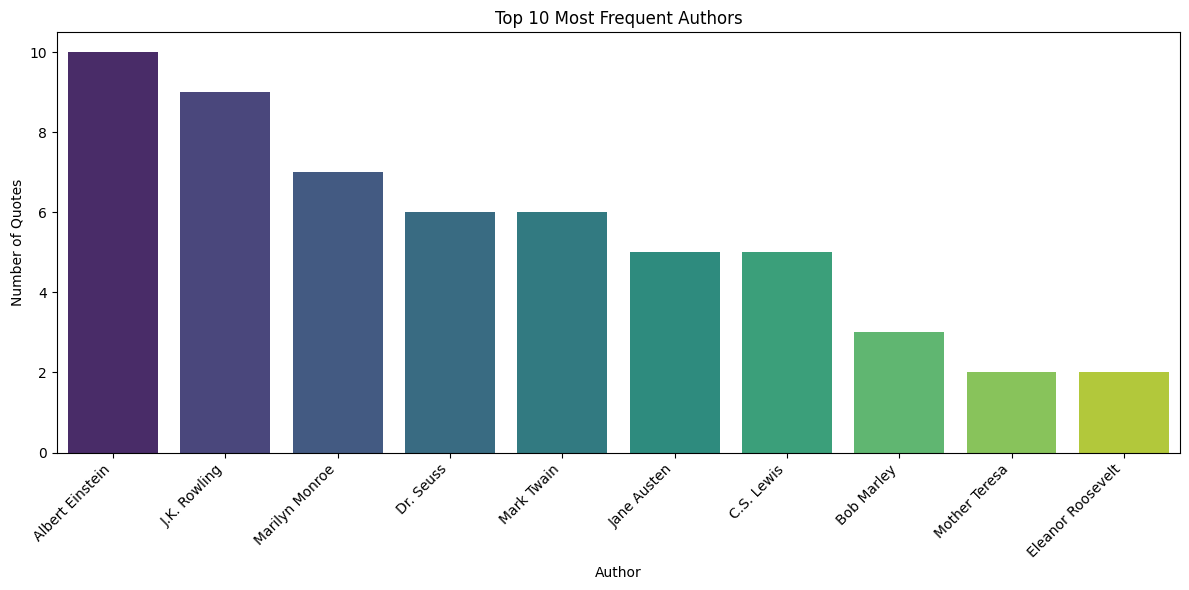

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure author_counts is available. If running this cell independently, uncomment:
# df_quotes = pd.read_csv('quotes.csv') # Assuming tags are stored as strings (e.g., 'tag1, tag2')
# df_quotes['tags'] = df_quotes['tags'].apply(lambda x: eval(x) if isinstance(x, str) else x)
# author_counts = df_quotes['author'].value_counts()

# Get the top 10 most frequent authors
top_10_authors = author_counts.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_authors.index, y=top_10_authors.values, palette='viridis')
plt.title('Top 10 Most Frequent Authors')
plt.xlabel('Author')
plt.ylabel('Number of Quotes')
plt.xticks(rotation=45, ha='right') # Rotate author names for better readability
plt.tight_layout()
plt.show()


Let's export the top 10 most frequent authors and tags into a new CSV file for easy access and further use.

In [ ]:
import pandas as pd

# Get the top 10 most frequent authors and tags
top_10_authors_df = author_counts.head(10).reset_index()
top_10_authors_df.columns = ['Author', 'Quote_Count']

top_10_tags_df = tag_counts.head(10).reset_index()
top_10_tags_df.columns = ['Tag', 'Quote_Count']

# Combine them into a single DataFrame or save separately
# For simplicity, let's create a dictionary of DataFrames and save them to a single Excel file with multiple sheets,
# or separate CSVs.

# Option 1: Save to separate CSV files
top_10_authors_df.to_csv('top_10_authors.csv', index=False, encoding='utf-8')
top_10_tags_df.to_csv('top_10_tags.csv', index=False, encoding='utf-8')

print("Analysis results exported to 'top_10_authors.csv' and 'top_10_tags.csv'.")

# Option 2 (Alternative): Save to a single Excel file with multiple sheets
# excel_filename = 'quotes_analysis.xlsx'
# with pd.ExcelWriter(excel_filename) as writer:
#     top_10_authors_df.to_excel(writer, sheet_name='Top Authors', index=False)
#     top_10_tags_df.to_excel(writer, sheet_name='Top Tags', index=False)
# print(f"Analysis results exported to '{excel_filename}'.")


Analysis results exported to 'top_10_authors.csv' and 'top_10_tags.csv'.


The top 10 most frequent authors and tags have been saved to `top_10_authors.csv` and `top_10_tags.csv` respectively. These files are now available in your Colab environment.